# Measuring Late-Clock Defensive Pressure

This project asks whether defenses that force opponents into late-clock outcomes tend to have stronger overall defensive performance.

Instead of only counting shot-clock violations, I build a broader Late Clock Pressure Index (LCPI) that includes:
- shot-clock violations forced
- pressure-related turnovers forced
- difficult/desperation missed shots forced

The goal is to test whether this custom pressure metric relates to team defensive rating.

In [1]:
import pandas as pd
import time
import re
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio


from nba_api.stats.endpoints import playbyplayv3, leaguegamefinder, leaguedashteamstats

In [2]:
valid_teams = {
    "ATL","BOS","BKN","CHA","CHI","CLE","DAL","DEN","DET","GSW",
    "HOU","IND","LAC","LAL","MEM","MIA","MIL","MIN","NOP","NYK",
    "OKC","ORL","PHI","PHX","POR","SAC","SAS","TOR","UTA","WAS"
}

team_map = {
    "HAWKS": "ATL", "CELTICS": "BOS", "NETS": "BKN", "HORNETS": "CHA",
    "BULLS": "CHI", "CAVALIERS": "CLE", "MAVERICKS": "DAL", "NUGGETS": "DEN",
    "PISTONS": "DET", "WARRIORS": "GSW", "ROCKETS": "HOU", "PACERS": "IND",
    "CLIPPERS": "LAC", "LAKERS": "LAL", "GRIZZLIES": "MEM", "HEAT": "MIA",
    "BUCKS": "MIL", "TIMBERWOLVES": "MIN", "PELICANS": "NOP", "KNICKS": "NYK",
    "THUNDER": "OKC", "MAGIC": "ORL", "76ERS": "PHI", "SUNS": "PHX",
    "TRAIL BLAZERS": "POR", "BLAZERS": "POR", "KINGS": "SAC", "SPURS": "SAS",
    "RAPTORS": "TOR", "JAZZ": "UTA", "WIZARDS": "WAS"
}

def extract_offense_team(desc):
    if pd.isna(desc):
        return None
    match = re.match(r"^(.*?)\s+Turnover:\s+Shot Clock", str(desc), flags=re.IGNORECASE)
    return match.group(1).strip().upper() if match else None

In [3]:
games_df = leaguegamefinder.LeagueGameFinder(
    season_nullable="2021-22",
    league_id_nullable="00"
).get_data_frames()[0]

game_ids = games_df["GAME_ID"].drop_duplicates().tolist()

len(game_ids), game_ids[:5]

(1394, ['0042100406', '0042100405', '0042100404', '0042100403', '0042100402'])

In [5]:
team_game_rows = []
bad_games = []

for i, game_id in enumerate(game_ids):
    try:
        pbp_df = playbyplayv3.PlayByPlayV3(game_id=game_id).get_data_frames()[0]

        teams = [t for t in pbp_df["teamTricode"].dropna().unique() if t != ""]
        shotclock_df = pbp_df[pbp_df["subType"] == "Shot Clock Turnover"].copy()

        for team in teams:
            team_df = pbp_df[pbp_df["teamTricode"] == team]

            fga = team_df[team_df["actionType"].isin(["Made Shot", "Missed Shot"])].shape[0]
            tov = team_df[team_df["actionType"] == "Turnover"].shape[0]
            fta = team_df[team_df["actionType"] == "Free Throw"].shape[0]

            possessions = fga + tov + 0.44 * fta

            shotclock_forced = 0

            for _, row in shotclock_df.iterrows():
                offense_name = extract_offense_team(row["description"])
                offense_team = team_map.get(offense_name)

                if offense_team is not None and offense_team != team:
                    shotclock_forced += 1

            team_game_rows.append({
                "game_id": game_id,
                "team": team,
                "possessions": possessions,
                "shotclock_forced": shotclock_forced
            })

        if i % 50 == 0:
            print(f"Processed {i}/{len(game_ids)} games")

        time.sleep(1)

    except Exception as e:
        bad_games.append({"game_id": game_id, "error": str(e)})
        print(f"Error with game {game_id}: {e}")

Processed 0/1394 games
Processed 50/1394 games
Processed 100/1394 games
Processed 150/1394 games
Processed 200/1394 games
Processed 250/1394 games
Processed 300/1394 games
Processed 350/1394 games
Processed 400/1394 games
Processed 450/1394 games
Processed 500/1394 games
Processed 550/1394 games
Processed 600/1394 games
Processed 650/1394 games
Processed 700/1394 games
Processed 750/1394 games
Processed 800/1394 games
Processed 850/1394 games
Processed 900/1394 games
Processed 950/1394 games
Processed 1000/1394 games
Processed 1050/1394 games
Processed 1100/1394 games
Processed 1150/1394 games
Processed 1200/1394 games
Processed 1250/1394 games
Processed 1300/1394 games
Processed 1350/1394 games


In [6]:
team_game_df = pd.DataFrame(team_game_rows)
bad_games_df = pd.DataFrame(bad_games)

team_game_df.head(), bad_games_df.head()

(      game_id team  possessions  shotclock_forced
 0  0042100406  BOS       107.28                 2
 1  0042100406  GSW       110.52                 1
 2  0042100405  GSW       100.60                 0
 3  0042100405  BOS       106.64                 1
 4  0042100404  BOS       108.36                 0,
 Empty DataFrame
 Columns: []
 Index: [])

## Baseline: Shot-Clock Violations Forced

I first measured how often each team forced opponents into shot-clock violations. This is the cleanest late-clock pressure outcome, but it is also rare. Because shot-clock violations happen infrequently, this metric may miss many possessions where the defense still successfully disrupted the offense late in the clock.

I normalize all forced events per 100 estimated possessions so teams can be compared fairly despite playing different numbers of games and possessions.

Estimated possessions are calculated as:

`FGA + TOV + 0.44 * FTA`

This is a simplified possession estimate commonly used in basketball analytics.

In [7]:
team_stats_df = (
    team_game_df
    .groupby("team", as_index=False)
    .agg(
        games_played=("game_id", "nunique"),
        possessions=("possessions", "sum"),
        shotclock_forced=("shotclock_forced", "sum")
    )
)

team_stats_df["shotclock_forced_per_100"] = (
    team_stats_df["shotclock_forced"] / team_stats_df["possessions"] * 100
)

team_stats_df = team_stats_df.sort_values(
    "shotclock_forced_per_100",
    ascending=False
).reset_index(drop=True)

team_stats_df

,team,games_played,possessions,shotclock_forced,shotclock_forced_per_100
0,PHI,98,10441.36,78,0.747029
1,BKN,91,10092.88,75,0.743098
2,BOS,110,11980.68,85,0.709476
3,TOR,93,10437.68,73,0.699389
4,SAC,86,9636.40,67,0.695280
5,GSW,109,11983.56,83,0.692616
6,IND,86,9683.88,66,0.681545
7,NYK,86,9412.84,64,0.679922
8,MIA,106,11477.92,78,0.679566
9,MIN,93,10668.64,72,0.674875


In [ ]:
team_game_df.to_csv("team_game_shotclock_data_2021_22.csv", index=False)
team_stats_df.to_csv("team_shotclock_forced_per100_2021_22.csv", index=False)
bad_games_df.to_csv("bad_games_2021_22.csv", index=False)

In [ ]:
drtg_df = leaguedashteamstats.LeagueDashTeamStats(
    season='2021-22',
    measure_type_detailed_defense='Advanced'
).get_data_frames()[0]

drtg_df

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,...,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK
0,1610612737,Atlanta Hawks,82,43,39,0.524,3941.0,114.0,115.4,112.1,...,4,14,17,12,14,1,8,6,17,14
1,1610612738,Boston Celtics,82,51,31,0.622,3981.0,112.1,113.6,104.0,...,11,10,11,16,10,13,9,9,24,2
2,1610612751,Brooklyn Nets,82,44,38,0.537,3951.0,111.0,113.2,109.6,...,13,9,9,30,15,18,11,11,11,11
3,1610612766,Charlotte Hornets,82,43,39,0.524,3976.0,111.7,113.6,111.0,...,2,2,14,29,27,9,7,13,5,15
4,1610612741,Chicago Bulls,82,46,36,0.561,3946.0,111.0,112.7,111.1,...,10,17,28,7,17,6,10,8,14,20
5,1610612739,Cleveland Cavaliers,82,44,38,0.537,3946.0,109.4,111.0,107.0,...,21,7,12,18,12,27,14,15,25,7
6,1610612742,Dallas Mavericks,82,52,30,0.634,3951.0,110.5,112.5,106.8,...,9,18,23,10,16,7,13,14,30,12
7,1610612743,Denver Nuggets,82,48,34,0.585,3961.0,111.7,113.8,110.3,...,6,1,19,1,4,26,1,1,20,9
8,1610612765,Detroit Pistons,82,23,59,0.280,3956.0,103.3,105.6,111.1,...,23,24,13,26,30,20,30,29,13,29
9,1610612744,Golden State Warriors,82,53,29,0.646,3946.0,110.5,112.1,103.9,...,12,3,15,6,8,29,3,4,15,3


In [10]:
full_name_to_tricode = {
    "Atlanta Hawks": "ATL",
    "Boston Celtics": "BOS",
    "Brooklyn Nets": "BKN",
    "Charlotte Hornets": "CHA",
    "Chicago Bulls": "CHI",
    "Cleveland Cavaliers": "CLE",
    "Dallas Mavericks": "DAL",
    "Denver Nuggets": "DEN",
    "Detroit Pistons": "DET",
    "Golden State Warriors": "GSW",
    "Houston Rockets": "HOU",
    "Indiana Pacers": "IND",
    "LA Clippers": "LAC",
    "Los Angeles Lakers": "LAL",
    "Memphis Grizzlies": "MEM",
    "Miami Heat": "MIA",
    "Milwaukee Bucks": "MIL",
    "Minnesota Timberwolves": "MIN",
    "New Orleans Pelicans": "NOP",
    "New York Knicks": "NYK",
    "Oklahoma City Thunder": "OKC",
    "Orlando Magic": "ORL",
    "Philadelphia 76ers": "PHI",
    "Phoenix Suns": "PHX",
    "Portland Trail Blazers": "POR",
    "Sacramento Kings": "SAC",
    "San Antonio Spurs": "SAS",
    "Toronto Raptors": "TOR",
    "Utah Jazz": "UTA",
    "Washington Wizards": "WAS"
}

In [11]:
drtg_df = drtg_df[["TEAM_NAME", "DEF_RATING"]].copy()
drtg_df["team"] = drtg_df["TEAM_NAME"].map(full_name_to_tricode)
drtg_df = drtg_df[["team", "DEF_RATING"]].rename(columns={"DEF_RATING": "def_rating"})

merged_df = team_stats_df.merge(drtg_df, on="team", how="inner")

merged_df

,team,games_played,possessions,shotclock_forced,shotclock_forced_per_100,def_rating
0,PHI,98,10441.36,78,0.747029,110.2
1,BKN,91,10092.88,75,0.743098,112.3
2,BOS,110,11980.68,85,0.709476,106.2
3,TOR,93,10437.68,73,0.699389,109.9
4,SAC,86,9636.40,67,0.695280,114.8
5,GSW,109,11983.56,83,0.692616,106.6
6,IND,86,9683.88,66,0.681545,115.5
7,NYK,86,9412.84,64,0.679922,110.2
8,MIA,106,11477.92,78,0.679566,108.4
9,MIN,93,10668.64,72,0.674875,111.0


In [12]:
corr = merged_df['shotclock_forced_per_100'].corr(merged_df['def_rating'])
print(f'Correlation: {corr:.2f}')

Correlation: -0.07


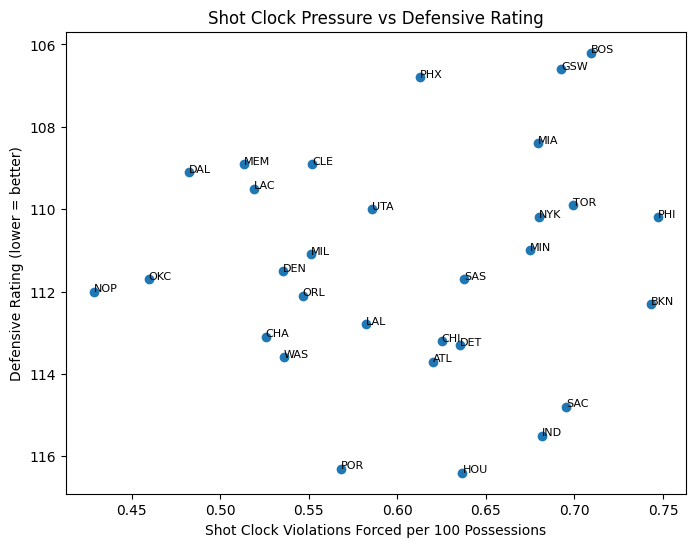

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    merged_df["shotclock_forced_per_100"],
    merged_df["def_rating"]
)

for _, row in merged_df.iterrows():
    plt.text(
        row["shotclock_forced_per_100"],
        row["def_rating"],
        row["team"],
        fontsize=8
    )

plt.xlabel("Shot Clock Violations Forced per 100 Possessions")
plt.ylabel("Defensive Rating (lower = better)")
plt.title("Shot Clock Pressure vs Defensive Rating")

plt.gca().invert_yaxis()  # important
plt.show()

In [14]:
valid_teams = {
    "ATL","BOS","BKN","CHA","CHI","CLE","DAL","DEN","DET","GSW",
    "HOU","IND","LAC","LAL","MEM","MIA","MIL","MIN","NOP","NYK",
    "OKC","ORL","PHI","PHX","POR","SAC","SAS","TOR","UTA","WAS"
}

team_map = {
    "HAWKS": "ATL", "CELTICS": "BOS", "NETS": "BKN", "HORNETS": "CHA",
    "BULLS": "CHI", "CAVALIERS": "CLE", "MAVERICKS": "DAL", "NUGGETS": "DEN",
    "PISTONS": "DET", "WARRIORS": "GSW", "ROCKETS": "HOU", "PACERS": "IND",
    "CLIPPERS": "LAC", "LAKERS": "LAL", "GRIZZLIES": "MEM", "HEAT": "MIA",
    "BUCKS": "MIL", "TIMBERWOLVES": "MIN", "PELICANS": "NOP", "KNICKS": "NYK",
    "THUNDER": "OKC", "MAGIC": "ORL", "76ERS": "PHI", "SUNS": "PHX",
    "TRAIL BLAZERS": "POR", "BLAZERS": "POR", "KINGS": "SAC", "SPURS": "SAS",
    "RAPTORS": "TOR", "JAZZ": "UTA", "WIZARDS": "WAS"
}

def extract_shotclock_offense(desc):
    if pd.isna(desc):
        return None
    match = re.match(r"^(.*?)\s+Turnover:\s+Shot Clock", str(desc), flags=re.IGNORECASE)
    return team_map.get(match.group(1).strip().upper()) if match else None

def get_opponent(team, teams):
    opponents = [t for t in teams if t != team]
    return opponents[0] if opponents else None

In [ ]:
games_df = leaguegamefinder.LeagueGameFinder(
    season_nullable="2021-22",
    league_id_nullable="00"
).get_data_frames()[0]

game_ids = games_df["GAME_ID"].drop_duplicates().tolist()

# regular season + playoffs only
game_ids = [gid for gid in game_ids if str(gid).startswith(("002", "004"))]

len(game_ids), game_ids[:5]

(1314, ['0042200405', '0042200404', '0042200403', '0042200402', '0042200401'])

In [16]:
final_rows = []
bad_games = []

pressure_turnover_types = [
    "Bad Pass",
    "Lost Ball",
    "Out of Bounds Lost Ball Turnover",
    "Offensive Foul Turnover"
]

desperation_shot_terms = (
    "heave|buzzer|running|fadeaway|step back|pullup|pull-up|"
    "turnaround|floating|floater|hook"
)

for i, game_id in enumerate(game_ids):
    try:
        pbp_df = playbyplayv3.PlayByPlayV3(game_id=game_id).get_data_frames()[0]

        teams = [t for t in pbp_df["teamTricode"].dropna().unique() if t in valid_teams]

        if len(teams) != 2:
            continue

        shotclock_df = pbp_df[pbp_df["subType"] == "Shot Clock Turnover"].copy()

        pressure_tov_df = pbp_df[
            (pbp_df["actionType"] == "Turnover") &
            (pbp_df["subType"].isin(pressure_turnover_types))
        ].copy()

        desperation_miss_df = pbp_df[
            (pbp_df["actionType"] == "Missed Shot") &
            (pbp_df["description"].str.contains(desperation_shot_terms, case=False, na=False))
        ].copy()

        for team in teams:
            opponent = get_opponent(team, teams)
            team_df = pbp_df[pbp_df["teamTricode"] == team]

            fga = team_df[team_df["actionType"].isin(["Made Shot", "Missed Shot"])].shape[0]
            tov = team_df[team_df["actionType"] == "Turnover"].shape[0]
            fta = team_df[team_df["actionType"] == "Free Throw"].shape[0]

            possessions = fga + tov + 0.44 * fta

            shotclock_forced = 0
            for _, row in shotclock_df.iterrows():
                offense_team = extract_shotclock_offense(row["description"])
                if offense_team == opponent:
                    shotclock_forced += 1

            pressure_turnovers_forced = pressure_tov_df[
                pressure_tov_df["teamTricode"] == opponent
            ].shape[0]

            desperation_misses_forced = desperation_miss_df[
                desperation_miss_df["teamTricode"] == opponent
            ].shape[0]

            final_rows.append({
                "game_id": game_id,
                "team": team,
                "opponent": opponent,
                "possessions": possessions,
                "shotclock_forced": shotclock_forced,
                "pressure_turnovers_forced": pressure_turnovers_forced,
                "desperation_misses_forced": desperation_misses_forced
            })

        if i % 50 == 0:
            print(f"Processed {i}/{len(game_ids)} games")

        time.sleep(1)

    except Exception as e:
        bad_games.append({"game_id": game_id, "error": str(e)})
        print(f"Error with game {game_id}: {e}")

Processed 0/1314 games
Processed 50/1314 games
Processed 100/1314 games
Processed 150/1314 games
Processed 200/1314 games
Processed 250/1314 games
Processed 300/1314 games
Processed 350/1314 games
Processed 400/1314 games
Processed 450/1314 games
Processed 500/1314 games
Processed 550/1314 games
Processed 600/1314 games
Processed 650/1314 games
Processed 700/1314 games
Error with game 0022200587: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)
Processed 750/1314 games
Processed 800/1314 games
Processed 850/1314 games
Processed 900/1314 games
Processed 950/1314 games
Processed 1000/1314 games
Processed 1050/1314 games
Processed 1100/1314 games
Processed 1150/1314 games
Processed 1200/1314 games
Processed 1250/1314 games
Processed 1300/1314 games


In [17]:
final_team_game_df = pd.DataFrame(final_rows)
bad_games_df = pd.DataFrame(bad_games)

final_team_game_df.head()

,game_id,team,opponent,possessions,shotclock_forced,pressure_turnovers_forced,desperation_misses_forced
0,0042200405,DEN,MIA,108.12,0,6,35
1,0042200405,MIA,DEN,111.04,1,10,25
2,0042200404,MIA,DEN,100.80,2,4,23
3,0042200404,DEN,MIA,94.24,1,11,25
4,0042200403,MIA,DEN,104.36,1,11,24


## Expanding the Metric: Late Clock Pressure Index

Shot-clock violations are only one visible result of late-clock pressure. A defense can also create value by forcing rushed passes, lost-ball turnovers, offensive fouls, or difficult late-clock shot attempts.

To capture this broader idea, I created a Late Clock Pressure Index (LCPI):

LCPI = shot-clock violations forced + 0.5 * pressure turnovers forced + 0.5 * desperation misses forced

The 0.5 weights are intentionally conservative because these events are less direct indicators of late-clock pressure than actual shot-clock violations.

In [18]:
final_team_stats_df = (
    final_team_game_df
    .groupby("team", as_index=False)
    .agg(
        games_played=("game_id", "nunique"),
        possessions=("possessions", "sum"),
        shotclock_forced=("shotclock_forced", "sum"),
        pressure_turnovers_forced=("pressure_turnovers_forced", "sum"),
        desperation_misses_forced=("desperation_misses_forced", "sum")
    )
)

final_team_stats_df["shotclock_forced_per_100"] = (
    final_team_stats_df["shotclock_forced"] / final_team_stats_df["possessions"] * 100
)

final_team_stats_df["pressure_turnovers_forced_per_100"] = (
    final_team_stats_df["pressure_turnovers_forced"] / final_team_stats_df["possessions"] * 100
)

final_team_stats_df["desperation_misses_forced_per_100"] = (
    final_team_stats_df["desperation_misses_forced"] / final_team_stats_df["possessions"] * 100
)

final_team_stats_df["lcpi_per_100"] = (
    (
        final_team_stats_df["shotclock_forced"] * 1.0 +
        final_team_stats_df["pressure_turnovers_forced"] * 0.5 +
        final_team_stats_df["desperation_misses_forced"] * 0.5
    )
    / final_team_stats_df["possessions"] * 100
)

final_team_stats_df = final_team_stats_df.sort_values(
    "lcpi_per_100",
    ascending=False
).reset_index(drop=True)

final_team_stats_df.head(10)

,team,games_played,possessions,shotclock_forced,pressure_turnovers_forced,desperation_misses_forced,shotclock_forced_per_100,pressure_turnovers_forced_per_100,desperation_misses_forced_per_100,lcpi_per_100
0,BOS,102,11226.36,75,942,2496,0.668071,8.390966,22.233386,15.980246
1,CLE,87,9324.28,90,928,1860,0.965222,9.952511,19.947921,15.915438
2,BKN,86,9218.96,60,829,1956,0.650833,8.992338,21.217144,15.755573
3,MIL,87,9937.36,29,751,2222,0.291828,7.557339,22.360063,15.250529
4,PHX,93,10419.72,75,941,1991,0.719789,9.030953,19.107999,14.789265
5,PHI,93,9961.92,66,918,1888,0.662523,9.215091,18.952170,14.746153
6,LAL,98,11110.76,50,893,2282,0.450014,8.037254,20.538649,14.737966
7,MIN,86,9648.96,55,952,1778,0.570010,9.866348,18.426856,14.716612
8,LAC,86,9482.48,55,766,1910,0.580017,8.078056,20.142410,14.690250
9,MEM,88,10171.36,66,948,1876,0.648881,9.320288,18.443945,14.530997


In [19]:
final_team_game_df.to_csv("final_team_game_lcpi_2022_23.csv", index=False)
final_team_stats_df.to_csv("final_team_lcpi_2022_23.csv", index=False)
bad_games_df.to_csv("bad_games_lcpi_2022_23.csv", index=False)

In [20]:
final_team_stats_df

,team,games_played,possessions,shotclock_forced,pressure_turnovers_forced,desperation_misses_forced,shotclock_forced_per_100,pressure_turnovers_forced_per_100,desperation_misses_forced_per_100,lcpi_per_100
0,BOS,102,11226.36,75,942,2496,0.668071,8.390966,22.233386,15.980246
1,CLE,87,9324.28,90,928,1860,0.965222,9.952511,19.947921,15.915438
2,BKN,86,9218.96,60,829,1956,0.650833,8.992338,21.217144,15.755573
3,MIL,87,9937.36,29,751,2222,0.291828,7.557339,22.360063,15.250529
4,PHX,93,10419.72,75,941,1991,0.719789,9.030953,19.107999,14.789265
5,PHI,93,9961.92,66,918,1888,0.662523,9.215091,18.952170,14.746153
6,LAL,98,11110.76,50,893,2282,0.450014,8.037254,20.538649,14.737966
7,MIN,86,9648.96,55,952,1778,0.570010,9.866348,18.426856,14.716612
8,LAC,86,9482.48,55,766,1910,0.580017,8.078056,20.142410,14.690250
9,MEM,88,10171.36,66,948,1876,0.648881,9.320288,18.443945,14.530997


In [22]:
final_team_stats_df = final_team_stats_df.merge(drtg_df,
                                                on='team',
                                                how='inner'
)
final_team_stats_df

,team,games_played,possessions,shotclock_forced,pressure_turnovers_forced,desperation_misses_forced,shotclock_forced_per_100,pressure_turnovers_forced_per_100,desperation_misses_forced_per_100,lcpi_per_100,def_rating
0,BOS,102,11226.36,75,942,2496,0.668071,8.390966,22.233386,15.980246,106.2
1,CLE,87,9324.28,90,928,1860,0.965222,9.952511,19.947921,15.915438,108.9
2,BKN,86,9218.96,60,829,1956,0.650833,8.992338,21.217144,15.755573,112.3
3,MIL,87,9937.36,29,751,2222,0.291828,7.557339,22.360063,15.250529,111.1
4,PHX,93,10419.72,75,941,1991,0.719789,9.030953,19.107999,14.789265,106.8
5,PHI,93,9961.92,66,918,1888,0.662523,9.215091,18.952170,14.746153,110.2
6,LAL,98,11110.76,50,893,2282,0.450014,8.037254,20.538649,14.737966,112.8
7,MIN,86,9648.96,55,952,1778,0.570010,9.866348,18.426856,14.716612,111.0
8,LAC,86,9482.48,55,766,1910,0.580017,8.078056,20.142410,14.690250,109.5
9,MEM,88,10171.36,66,948,1876,0.648881,9.320288,18.443945,14.530997,108.9


## Results

The shot-clock-only metric had a modest relationship with defensive rating, but the broader LCPI metric had a stronger negative correlation with defensive rating.

Because lower defensive rating is better, a negative correlation means that teams with higher LCPI scores tended to allow fewer points per 100 possessions.

This suggests that late-clock pressure may be connected to overall defensive quality, especially when measured with a broader set of outcomes rather than shot-clock violations alone.

## Limitations

This metric is exploratory and has several limitations:

- Some “desperation shot” labels are inferred from play-by-play descriptions, so they may include false positives.
- The LCPI weights are heuristic rather than learned from a model.
- Correlation does not prove that late-clock pressure causes better defensive rating.
- Playoff and regular-season games are currently combined, which may affect team comparisons.
- The possession estimate is simplified and does not perfectly match official possession calculations.

In [24]:
print("Shot Clock Only:",
      final_team_stats_df["shotclock_forced_per_100"].corr(final_team_stats_df["def_rating"]))

print("Pressure Turnovers:",
      final_team_stats_df["pressure_turnovers_forced_per_100"].corr(final_team_stats_df["def_rating"]))

print("Desperation Misses:",
      final_team_stats_df["desperation_misses_forced_per_100"].corr(final_team_stats_df["def_rating"]))

print("LCPI:",
      final_team_stats_df["lcpi_per_100"].corr(final_team_stats_df["def_rating"]))

Shot Clock Only: -0.3084825609626045
Pressure Turnovers: -0.07586879397076005
Desperation Misses: -0.43765696144275906
LCPI: -0.5539747536691626


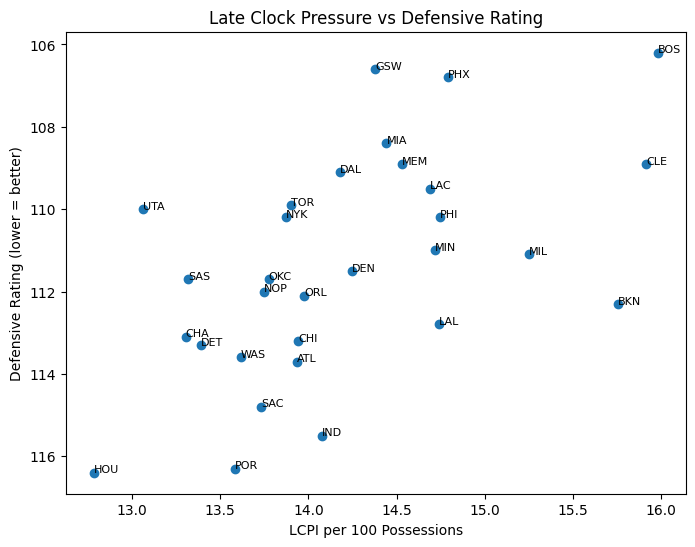

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    final_team_stats_df["lcpi_per_100"],
    final_team_stats_df["def_rating"]
)

for _, row in final_team_stats_df.iterrows():
    plt.text(row["lcpi_per_100"], row["def_rating"], row["team"], fontsize=8)

plt.xlabel("LCPI per 100 Possessions")
plt.ylabel("Defensive Rating (lower = better)")
plt.title("Late Clock Pressure vs Defensive Rating")

plt.gca().invert_yaxis()
plt.show()

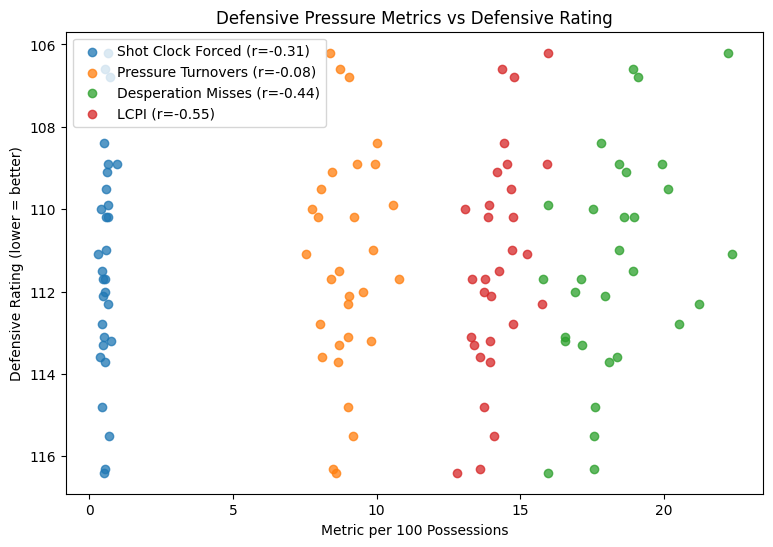

In [ ]:
metrics = {
    "Shot Clock Forced": "shotclock_forced_per_100",
    "Pressure Turnovers": "pressure_turnovers_forced_per_100",
    "Desperation Misses": "desperation_misses_forced_per_100",
    "LCPI": "lcpi_per_100"
}

plt.figure(figsize=(9, 6))

for label, col in metrics.items():
    corr = final_team_stats_df[col].corr(final_team_stats_df["def_rating"])
    
    plt.scatter(
        final_team_stats_df[col],
        final_team_stats_df["def_rating"],
        label=f"{label} (r={corr:.2f})",
        alpha=0.75
    )

plt.xlabel("Metric per 100 Possessions")
plt.ylabel("Defensive Rating (lower = better)")
plt.title("Defensive Pressure Metrics vs Defensive Rating")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

## Standardizing the Metrics with Z-Scores

The raw values for shot-clock violations, pressure turnovers, desperation misses, and defensive rating all exist on very different numerical scales. Because of this, directly comparing them can be misleading.

To make the statistics comparable, I standardized each metric using z-scores.

A z-score measures how far a value is from the league average in terms of standard deviations:

z = (x - μ) / σ

Where:
- x = the team's value
- μ = league average
- σ = league standard deviation

Standardization allows each metric to be evaluated on the same relative scale. This makes it easier to:
- compare teams across different statistics
- identify which teams are unusually strong or weak in a category
- analyze relationships between the custom pressure metrics and defensive rating

Using z-scores also helps visualize whether teams that perform well in late-clock pressure metrics tend to perform above average defensively overall.

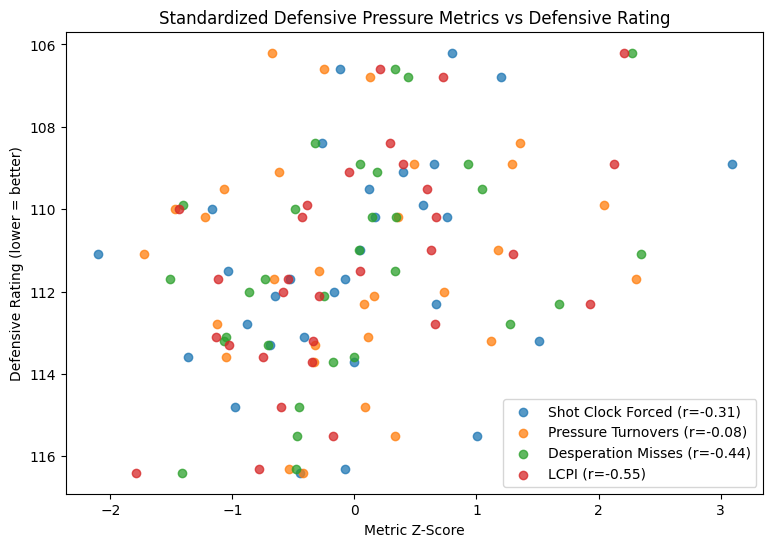

In [28]:
plot_df = final_team_stats_df.copy()

for col in metrics.values():
    plot_df[col + "_z"] = (plot_df[col] - plot_df[col].mean()) / plot_df[col].std()

plt.figure(figsize=(9, 6))

for label, col in metrics.items():
    z_col = col + "_z"
    corr = plot_df[col].corr(plot_df["def_rating"])
    
    plt.scatter(
        plot_df[z_col],
        plot_df["def_rating"],
        label=f"{label} (r={corr:.2f})",
        alpha=0.75
    )

plt.xlabel("Metric Z-Score")
plt.ylabel("Defensive Rating (lower = better)")
plt.title("Standardized Defensive Pressure Metrics vs Defensive Rating")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [ ]:
pio.renderers.default = "browser"

metrics = {
    "Shot Clock Forced": "shotclock_forced_per_100",
    "Pressure Turnovers": "pressure_turnovers_forced_per_100",
    "Desperation Misses": "desperation_misses_forced_per_100",
    "LCPI": "lcpi_per_100"
}

plot_rows = []

for metric_name, col in metrics.items():
    temp = final_team_stats_df[["team", "def_rating", col]].copy()
    
    temp["metric_value"] = temp[col]
    temp["metric_z_score"] = (temp[col] - temp[col].mean()) / temp[col].std()
    temp["metric"] = metric_name
    temp["correlation_with_drtg"] = temp[col].corr(temp["def_rating"])
    
    plot_rows.append(temp[[
        "team",
        "def_rating",
        "metric",
        "metric_value",
        "metric_z_score",
        "correlation_with_drtg"
    ]])

interactive_df = pd.concat(plot_rows, ignore_index=True)

fig = px.scatter(
    interactive_df,
    x="metric_z_score",
    y="def_rating",
    color="metric",
    hover_data={
        "team": True,
        "metric": True,
        "metric_value": ":.3f",
        "metric_z_score": ":.2f",
        "def_rating": ":.1f",
        "correlation_with_drtg": ":.2f"
    },
    title="Standardized Defensive Pressure Metrics vs Defensive Rating",
    labels={
        "metric_z_score": "Metric Z-Score",
        "def_rating": "Defensive Rating (lower = better)",
        "metric": "Metric"
    }
)

fig.update_yaxes(autorange="reversed")

fig.update_traces(
    marker=dict(size=10, opacity=0.75)
)

fig.update_layout(
    hovermode="closest",
    legend_title_text="Metric"
)

fig.show(renderer="browser")

## Conclusion

This project shows that a broader late-clock pressure metric may capture defensive value better than shot-clock violations alone. While shot-clock violations are rare, combining them with pressure turnovers and difficult missed shots creates a more informative view of how defenses disrupt possessions.

Future improvements could include separating regular season and playoffs, testing different LCPI weights, adding shot-clock time if available, and modeling whether LCPI predicts defensive rating better than traditional box-score defensive stats.